In [1]:
# general functions
import os
import cv2
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from collections import OrderedDict
# visualization
from PIL import Image
# identifying faces
#%pip install mtcnn
from mtcnn.mtcnn import MTCNN
# visualizing bounding boxes
import matplotlib.patches as patches
# CNN
import keras
from sklearn.model_selection import train_test_split
# Moving files between directories
import shutil
from shutil import unpack_archive
from subprocess import check_output

In [2]:
lfw_allnames = pd.read_csv("lfw_allnames.csv")

In [3]:
matchpairsDevTest = pd.read_csv("matchpairsDevTest.csv")
matchpairsDevTrain = pd.read_csv("matchpairsDevTrain.csv")
mismatchpairsDevTest = pd.read_csv("mismatchpairsDevTest.csv")
mismatchpairsDevTrain = pd.read_csv("mismatchpairsDevTrain.csv")
pairs = pd.read_csv("pairs.csv")


In [4]:
pairs = pairs.rename(columns={'name': 'name1', 'Unnamed: 3': 'name2'})
matched_pairs = pairs[pairs["name2"].isnull()].drop("name2", axis=1)
mismatched_pairs = pairs[pairs["name2"].notnull()]
people = pd.read_csv("people.csv")

In [5]:
people = people[people.name.notnull()]
peopleDevTest = pd.read_csv("peopleDevTest.csv")
peopleDevTrain = pd.read_csv("peopleDevTrain.csv")


In [6]:
lfw_allnames.head()

,name,images
0,AJ_Cook,1
1,AJ_Lamas,1
2,Aaron_Eckhart,1
3,Aaron_Guiel,1
4,Aaron_Patterson,1


# Exploratory Data Analysis (EDA)

In [8]:
print("Summary:")
print("There are " + 
      str(lfw_allnames.shape[0]) + 
      " unique celebrities in the entire dataset, of whom " + 
      str(sum(lfw_allnames.images > 1)) + 
      " are represented by multiple images. The entire number of images available is " + 
      str(sum(lfw_allnames.images)) + 
      ". The most represented celebrity is " + 
      str(lfw_allnames.iloc[lfw_allnames['images'].idxmax()][0]) + 
      ", with " + 
      str(max(lfw_allnames.images)) + 
      " unique images in the dataset.")

Summary:
There are 5749 unique celebrities in the entire dataset, of whom 1680 are represented by multiple images. The entire number of images available is 13233. The most represented celebrity is George_W_Bush, with 530 unique images in the dataset.


C:\Users\ASUS\AppData\Local\Temp\ipykernel_11308\170007965.py:9: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  str(lfw_allnames.iloc[lfw_allnames['images'].idxmax()][0]) +


In [9]:
# shape data frame so there is a row per image, matched to relevant jpg file
image_paths = lfw_allnames.loc[lfw_allnames.index.repeat(lfw_allnames['images'])]
image_paths['image_path'] = 1 + image_paths.groupby('name').cumcount()
image_paths['image_path'] = image_paths.image_path.apply(lambda x: '{0:0>4}'.format(x))
image_paths['image_path'] = image_paths.name + "/" + image_paths.name + "_" + image_paths.image_path + ".jpg"
image_paths = image_paths.drop("images", axis=1)  # Fixed drop

# Ensure reproducibility by setting a random seed
lfw_train, lfw_test = train_test_split(image_paths, test_size=0.2, random_state=42)

# Reset index and drop it
lfw_train = lfw_train.reset_index().drop("index", axis=1)
lfw_test = lfw_test.reset_index().drop("index", axis=1)

# Verify overlap and mismatch
print(len(set(lfw_train.name).intersection(set(lfw_test.name))))  # Should be 843
print(len(set(lfw_test.name) - set(lfw_train.name)))  # Should be 874


852
863


In [10]:
# Assuming image_paths.image_path contains the relative paths
widths = []
heights = []
files = image_paths.image_path

# Loop through image paths and extract width and height
for file in files:
    path = "lfw-deepfunneled/" + str(file)  # Relative path if working in the same folder
    im = Image.open(path)
    widths.append(im.width)
    heights.append(im.height)

# Creating a DataFrame and summarizing the image dimensions
pd.DataFrame({'height': heights, 'width': widths}).describe()


,height,width
count,13233.0,13233.0
mean,250.0,250.0
std,0.0,0.0
min,250.0,250.0
25%,250.0,250.0
50%,250.0,250.0
75%,250.0,250.0
max,250.0,250.0


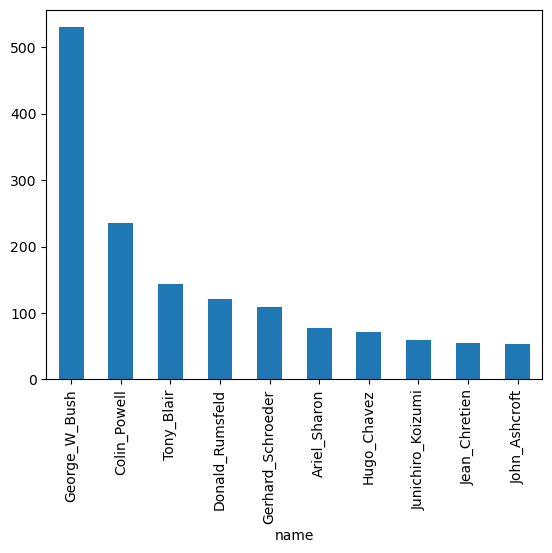

In [11]:
image_paths['name'].value_counts()[:10].plot(kind = "bar")
plt.show()

In [12]:
ind_counts = image_paths.groupby('name').count().image_path
print(str(sum(ind_counts[ind_counts==1])) + " individuals, which is " + str(round(100*(sum(ind_counts[ind_counts==1])/sum(ind_counts)))) + "% of the total individuals considered, are only represented by a single image in this dataset.")

4069 individuals, which is 31% of the total individuals considered, are only represented by a single image in this dataset.


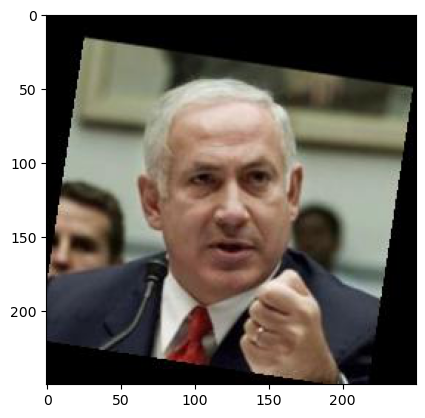

In [13]:
im = Image.open("lfw-deepfunneled/" + str(lfw_train.image_path[0]))  # Use relative path
plt.imshow(im)
plt.show()


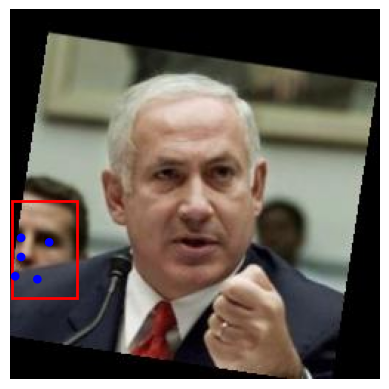

In [14]:
from mtcnn import MTCNN
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import os

# Assuming the images are inside a folder like "./lfw-deepfunneled/"
image_folder = "./lfw-deepfunneled/"
image_path = os.path.join(image_folder, str(lfw_train.image_path[0]))
image_bgr = cv2.imread(image_path)

if image_bgr is None:
    raise ValueError(f"Image not found at path: {image_path}")

# Convert BGR to RGB for MTCNN
image = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

# Run MTCNN detection
detector = MTCNN()
result = detector.detect_faces(image)

if not result:
    raise ValueError("No face detected in the image.")

# Get bounding box and keypoints
bounding_box = result[0]['box']
keypoints = result[0]['keypoints']

# Plot
fig, ax = plt.subplots(1)
ax.imshow(image)

# Draw bounding box
rect = patches.Rectangle(
    (bounding_box[0], bounding_box[1]),
    bounding_box[2], bounding_box[3],
    linewidth=2, edgecolor='r', facecolor='none'
)
ax.add_patch(rect)

# Draw keypoints
for key in keypoints:
    x, y = keypoints[key]
    kp = patches.Circle((x, y), radius=2, linewidth=2, edgecolor='b', facecolor='blue')
    ax.add_patch(kp)

plt.axis('off')
plt.show()


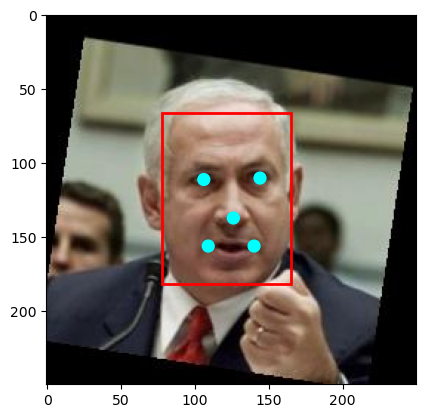

In [15]:
from mtcnn import MTCNN
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import os

# Assuming image_folder is defined and lfw_train.image_path[0] gives a valid relative path
image_path = os.path.join(image_folder, str(lfw_train.image_path[0]))

# Load and prepare image
image_bgr = cv2.imread(image_path)
if image_bgr is None:
    raise ValueError(f"Image not found at path: {image_path}")
image = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

# Detect faces
detector = MTCNN()
results = detector.detect_faces(image)

if not results:
    raise ValueError("No faces detected.")

# Select the largest face (most likely the main one)
def area(face):
    x, y, w, h = face['box']
    return w * h

largest_face = max(results, key=area)
bounding_box = largest_face['box']
keypoints = largest_face['keypoints']

# Plot
fig, ax = plt.subplots(1)
ax.imshow(image)

# Draw bounding box
rect = patches.Rectangle(
    (bounding_box[0], bounding_box[1]),
    bounding_box[2], bounding_box[3],
    linewidth=2, edgecolor='r', facecolor='none'
)
ax.add_patch(rect)

# Draw facial keypoints
for key in keypoints:
    x, y = keypoints[key]
    kp = patches.Circle((x, y), radius=4, linewidth=1, edgecolor='cyan', facecolor='cyan')
    ax.add_patch(kp)

In [16]:
not_george = image_paths[image_paths.name!="George_W_Bush"].sample(530)
not_george.name = "not_George"
GWB_data = pd.concat([image_paths[image_paths.name=="George_W_Bush"],
                     not_george])

In [17]:
# withhold final test data
bush_train, bush_test = train_test_split(GWB_data, test_size=0.2)
#  It is also useful to reserve a validation set in the training data, for use in the model construction
bush_train, bush_val = train_test_split(bush_train,test_size=0.2)

In [18]:
# initialize sequential network
from keras.models import Sequential
# include convolutional layers
from keras.layers import Conv2D
# Pooling layers
from keras.layers import MaxPooling2D
# flatten layers into single vector
from keras.layers import Flatten
from keras.layers import Dense

In [19]:
import os
import shutil

def directory_mover(data, dir_name):
    co = 0
    base_src = os.path.join('lfw-deepfunneled')
    base_dst = os.path.join('working', dir_name)

    for image in data.image_path:
        # get the category (person's name)
        data_type = data[data['image_path'] == image]['name']
        data_type = str(list(data_type)[0])

        # create destination directories if they don't exist
        dst_dir = os.path.join(base_dst, data_type)
        os.makedirs(dst_dir, exist_ok=True)

        path_from = os.path.join(base_src, image)
        path_to = os.path.join(dst_dir)

        try:
            shutil.copy(path_from, path_to)
            co += 1
        except FileNotFoundError:
            print(f"⚠️ File not found: {path_from}")

    print(f'Moved {co} images to {dir_name} folder.')


In [20]:
directory_mover(bush_train,"Bush_train/")
directory_mover(bush_val,"Bush_val/")
directory_mover(bush_test,"Bush_test/")

Moved 678 images to Bush_train/ folder.
Moved 170 images to Bush_val/ folder.
Moved 212 images to Bush_test/ folder.


In [21]:
from tensorflow import keras

train_datagen = keras.preprocessing.image.ImageDataGenerator(
    rescale=1./255,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)

test_datagen = keras.preprocessing.image.ImageDataGenerator(rescale=1./255)

Bush_training_set = train_datagen.flow_from_directory(
    'working/Bush_train/',
    target_size=(250, 250),
    batch_size=32,
    class_mode='binary'
)

Bush_val_set = test_datagen.flow_from_directory(
    'working/Bush_val/',
    target_size=(250, 250),
    batch_size=32,
    class_mode='binary'
)

Bush_test_set = test_datagen.flow_from_directory(
    'working/Bush_test/',
    target_size=(250, 250),
    batch_size=32,
    class_mode='binary'
)


Found 1135 images belonging to 2 classes.
Found 326 images belonging to 2 classes.
Found 399 images belonging to 2 classes.


In [22]:
from keras.layers import Conv2D,MaxPooling2D,Dense,Flatten,Dropout
from tensorflow.keras.optimizers import Adam
from keras.callbacks import TensorBoard
cnn_model = Sequential([
    Conv2D(filters=32,kernel_size=3,activation='relu',input_shape = (250, 250, 3)),
    MaxPooling2D(pool_size=2) ,# down sampling the output instead of 28*28 it is 14*14
    Dropout(0.2),
    Flatten(), # flatten out the layers
    Dense(32,activation='relu'),
    Dense(10,activation = 'softmax')
    
])

C:\Users\ASUS\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [23]:
from tensorflow.keras.optimizers import Adam

optimizer = Adam(learning_rate=0.001)
cnn_model.compile(loss='sparse_categorical_crossentropy', optimizer=optimizer, metrics=['accuracy'])


In [24]:
history = cnn_model.fit(
    Bush_training_set,
    batch_size=4096,
    epochs=75,
    verbose=1,
    validation_data=Bush_val_set
)

C:\Users\ASUS\anaconda3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/75
36/36 ━━━━━━━━━━━━━━━━━━━━ 53s 1s/step - accuracy: 0.4824 - loss: 6.7894 - val_accuracy: 0.6472 - val_loss: 0.7507
Epoch 2/75
36/36 ━━━━━━━━━━━━━━━━━━━━ 38s 1s/step - accuracy: 0.6730 - loss: 0.6395 - val_accuracy: 0.5613 - val_loss: 0.8195
Epoch 3/75
36/36 ━━━━━━━━━━━━━━━━━━━━ 37s 1s/step - accuracy: 0.6531 - loss: 0.6253 - val_accuracy: 0.6840 - val_loss: 0.6082
Epoch 4/75
36/36 ━━━━━━━━━━━━━━━━━━━━ 47s 1s/step - accuracy: 0.7867 - loss: 0.4909 - val_accuracy: 0.7178 - val_loss: 0.5527
Epoch 5/75
36/36 ━━━━━━━━━━━━━━━━━━━━ 31s 869ms/step - accuracy: 0.7808 - loss: 0.4684 - val_accuracy: 0.7393 - val_loss: 0.5000
Epoch 6/75
36/36 ━━━━━━━━━━━━━━━━━━━━ 36s 988ms/step - accuracy: 0.8116 - loss: 0.4047 - val_accuracy: 0.7515 - val_loss: 0.4742
Epoch 7/75
36/36 ━━━━━━━━━━━━━━━━━━━━ 39s 1s/step - accuracy: 0.8113 - loss: 0.4179 - val_accuracy: 0.8252 - val_loss: 0.3876
Epoch 8/75
36/36 ━━━━━━━━━━━━━━━━━━━━ 34s 937ms/step - accuracy: 0.8617 - loss: 0.3335 - val_accuracy: 0.8436 - 

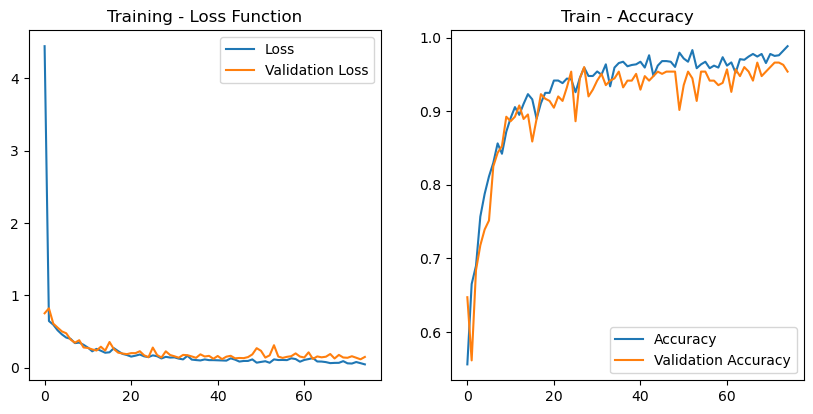

In [49]:
plt.figure(figsize=(10, 10))

plt.subplot(2, 2, 1)
plt.plot(history.history['loss'], label='Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title('Training - Loss Function')

plt.subplot(2, 2, 2)
plt.plot(history.history['accuracy'], label='Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title('Train - Accuracy')
plt.show()

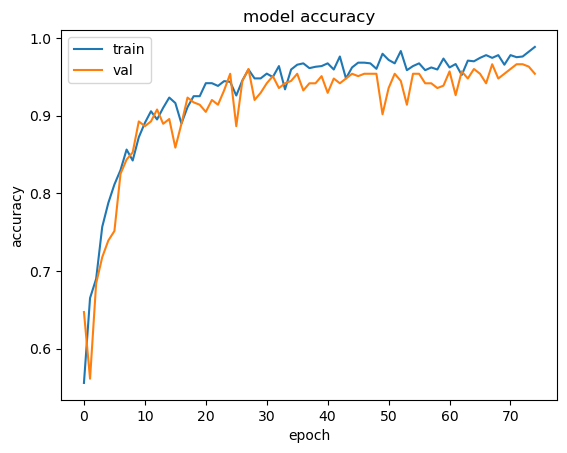

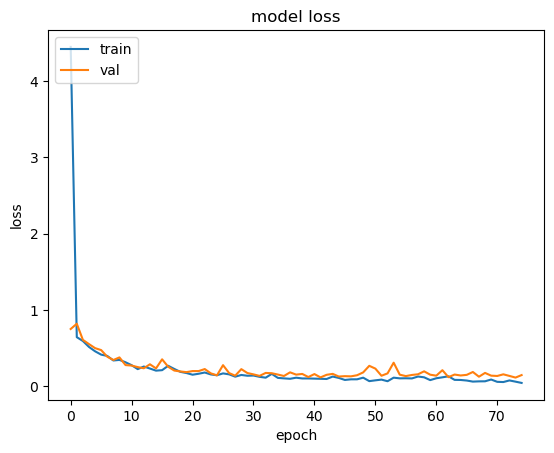

In [51]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

In [53]:
from keras.preprocessing import image

# create a function to predict class of images in a directory, given a trained classifier
def predictions(dir_name,classifier,binary):
    # dir_name should include name of predicted invididual - could edit this to iterate through folders in future
    predictions = []
    for im in os.listdir(dir_name):
        test_image = image.load_img(dir_name + str(im), target_size = (250,250))
        test_image = image.img_to_array(test_image)
        test_image = np.expand_dims(test_image, axis = 0)
        if(binary is True):
            result = float(str(classifier.predict(test_image))[2])
        else: 
            result = np.argmax(classifier.predict(test_image))
        predictions.append(result)
    return(predictions)

In [55]:
Bush_test_names = []
# collect all file names
for i in range(len(Bush_test_set.filenames)):
    Bush_test_names.append(Bush_test_set.filenames[i])
# extract unique names, in order
for i in range(len(Bush_test_names)):
    Bush_test_names[i] = Bush_test_names[i].split("/")[0]
Bush_test_name_order = list(OrderedDict.fromkeys(Bush_test_names))

In [57]:
Bush_test_name_order

['George_W_Bush\\George_W_Bush_0001.jpg',
 'George_W_Bush\\George_W_Bush_0003.jpg',
 'George_W_Bush\\George_W_Bush_0008.jpg',
 'George_W_Bush\\George_W_Bush_0009.jpg',
 'George_W_Bush\\George_W_Bush_0011.jpg',
 'George_W_Bush\\George_W_Bush_0013.jpg',
 'George_W_Bush\\George_W_Bush_0014.jpg',
 'George_W_Bush\\George_W_Bush_0015.jpg',
 'George_W_Bush\\George_W_Bush_0021.jpg',
 'George_W_Bush\\George_W_Bush_0022.jpg',
 'George_W_Bush\\George_W_Bush_0023.jpg',
 'George_W_Bush\\George_W_Bush_0026.jpg',
 'George_W_Bush\\George_W_Bush_0027.jpg',
 'George_W_Bush\\George_W_Bush_0036.jpg',
 'George_W_Bush\\George_W_Bush_0041.jpg',
 'George_W_Bush\\George_W_Bush_0042.jpg',
 'George_W_Bush\\George_W_Bush_0044.jpg',
 'George_W_Bush\\George_W_Bush_0045.jpg',
 'George_W_Bush\\George_W_Bush_0047.jpg',
 'George_W_Bush\\George_W_Bush_0050.jpg',
 'George_W_Bush\\George_W_Bush_0053.jpg',
 'George_W_Bush\\George_W_Bush_0057.jpg',
 'George_W_Bush\\George_W_Bush_0060.jpg',
 'George_W_Bush\\George_W_Bush_006

In [59]:
Bush_test_name_order[1]

'George_W_Bush\\George_W_Bush_0003.jpg'

In [61]:
Bush_predictions_0 = predictions("working/Bush_test/not_George/", cnn_model, binary=True)
Bush_predictions_1 = predictions("working/Bush_test/George_W_Bush/", cnn_model, binary=True)

# Compare predictions to actual classes
Bush_predictions_frame = pd.DataFrame(
    list(zip(
        Bush_predictions_0 + Bush_predictions_1,
        [0] * len(Bush_predictions_0) + [1] * len(Bush_predictions_1)
    )),
    columns=['Predictions', 'Actual']
)


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 723ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 187ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 198ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 245ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 170ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 163ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 210ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 163ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 194ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 378ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 172ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 215ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 201ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 

In [67]:
Bush_predictions_frame.sample(10)

,Predictions,Actual
387,0.0,1
308,1.0,1
217,1.0,1
370,1.0,1
41,0.0,0
273,0.0,1
117,0.0,0
174,0.0,0
170,0.0,0
13,0.0,0


In [69]:
# function for finding the precision and recall of predictions, for any number of predictive classes
def prec_acc(predictions_frame):
    precision = []
    accuracy = []
    recall = []
    for i in range(len(set(predictions_frame.Predictions))):
        tp = predictions_frame[np.logical_and(predictions_frame['Actual'] == i, predictions_frame['Predictions'] == i)].shape[0]
        tn = predictions_frame[np.logical_and(predictions_frame['Actual'] != i, predictions_frame['Predictions'] != i)].shape[0]
        fp = predictions_frame[np.logical_and(predictions_frame['Actual'] != i, predictions_frame['Predictions'] == i)].shape[0]
        fn = predictions_frame[np.logical_and(predictions_frame['Actual'] == i, predictions_frame['Predictions'] != i)].shape[0]
        total_preds = predictions_frame.shape[0]
        #precision.append(tp/(tp + fp))
        accuracy.append((tp + tn)/total_preds)
        #recall.append(tp/(tp + fn))
    #return(accuracy,precision,recall)
    return(accuracy)

In [71]:
Bush_accuracy = prec_acc(Bush_predictions_frame)
print('accuracy:' + str(Bush_accuracy[0]))
#print('Recall:' + str(Bush_accuracy[2]))
#print(Bush_test_name_order)

accuracy:0.8947368421052632
